In [1]:
import os
import sys
import json
from textwrap import wrap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sys.path.append(
    os.path.abspath(os.path.join(os.getcwd(), "../.."))
)  # Add parent directory to path

import json
import pandas as pd
import transformers
from datasets import load_dataset

from utils.helpers import parse_output

from utils.constants import DEFAULT_AUGMENT_RESULT

from utils.prompts import (
    JUDGE_SYSTEM_PROMPT,
    JUDGE_TEMPLATE,
    AUGMENT_SYSTEM_PROMPT,
    AUGMENT_TEMPLATE,
)

def wrap_text(text, num_chars):
    return '\n'.join(wrap(text, num_chars))

In [2]:
LABELS = ["yes", "no"] # Labels per column
EVAL_COLS = ['The exercise description matched the selected theme (Yes/Partially/No)',
       'The exercise description matched the selected topic (Yes/Partially/No)']
PLOT_COLS = ['The exercise description matched the selected theme (Yes/Partially/No)',
       'The exercise description matched the selected topic (Yes/Partially/No)',
       #'The exercise description matched the selected concept (Yes/No)'
            ]

def plot_distributions(df, axes, labels=LABELS, cols=PLOT_COLS):
    fig = axes[0].figure

    for i, col in enumerate(cols):
        sns.countplot(x=df[col], order=labels, ax=axes[i])
        axes[i].set_title(wrap_text(f"{col.upper()}", 20))
        axes[i].set_xlabel("")

    return fig, axes

In [3]:
# Load data
datapath = r"../../../data/planted_hallucinations_job_16583729.csv"
augmented_data = pd.read_csv(datapath, sep=";")

# Remove erroneous examples
mask_no_errors = (augmented_data[EVAL_COLS] != "PARSE ERROR").all(axis=1)

# Keep rows where evaluation columns are all "yes"
mask_all_yes = augmented_data[EVAL_COLS].eq("yes").all(axis=1)

augmented_data = augmented_data[mask_no_errors & mask_all_yes].reset_index()

augmented_data.head(1)

,index,title,problemDescription,exampleSolution,starterCode,tests,theme,topic,concept,difficulty,...,The exercise description matched the selected theme (Yes/Partially/No),The exercise description matched the selected topic (Yes/Partially/No),The exercise description matched the selected concept (Yes/No),Included concepts that were too advanced (Yes/No)\n,The exercise difficulty matched the selected difficulty (Too easy/Okay/Too difficult),Shallow vs deep personalization (Deep/Shallow/Unsure),Open field,prompt,augmentedProblemDescription,augmentedExampleSolution
0,0,Agatha Christie's Novel Ratings,"Agatha Christie, the famous novelist, has a ra...","{'code': ""import 'dart:io'; main() { print(...","{'code': ""import 'dart:io'; main() { }""}","{'testCode': ""import 'dart:async'; import 'pa...",literature,Agatha Christie,conditional statements,advanced,...,yes,yes,yes,no,too easy,shallow,NaN,Theme: literature\nTopic: Agatha Christie\nCon...,"""A bakery is famous for its delicious cakes. T...","{""code"": ""import 'dart:io'; main() { print(..."


In [4]:
flag = not True
if flag:
    first_occurrence_by_concept = [augmented_data["concept"].eq(concept).idxmax() for concept in augmented_data["concept"].unique()]
    for i in first_occurrence_by_concept:
        row = augmented_data.loc[i]
        
        print("Topic: " + row["topic"])
        print("Theme: " + row["theme"])
        print("Concept: " + row["concept"])
        print()
        print("Problem description: ", row["problemDescription"])
        print("Example solution: ", row["exampleSolution"])
        print()
        print("Augmented problem description: " + row["augmentedProblemDescription"])
        print("Augmented example solution: " + row["augmentedExampleSolution"])
        print()
        print("-------------------------------------------")
        print()

In [5]:
# Set non-faithful instances to real column
augmented_data["problemDescription"] = augmented_data["augmentedProblemDescription"]
augmented_data["exampleSolution"] = augmented_data["augmentedExampleSolution"]

# Flip labels
augmented_data[EVAL_COLS[0]] = "no"
augmented_data[EVAL_COLS[1]] = "no"


# Drop last three columns: prompt, augmentedProblemDescription, augmentedExampleSolution
augmented_data = augmented_data.iloc[:, :-3]

In [6]:
# Load original dataset
orig = r"../../../data/complete_dataset.csv"
original_dataset = pd.read_csv(orig, sep=";")

# Remove rows with label 'partially'
mask_no_partially = (original_dataset[EVAL_COLS] != "partially").all(axis=1)
pruned = original_dataset[mask_no_partially].reset_index()

#concated = pd.concat([original_dataset, augmented_data], ignore_index=True).iloc[:,:-1]

concated_with_pruned = pd.concat([pruned, augmented_data], ignore_index=True).iloc[:,:-1]

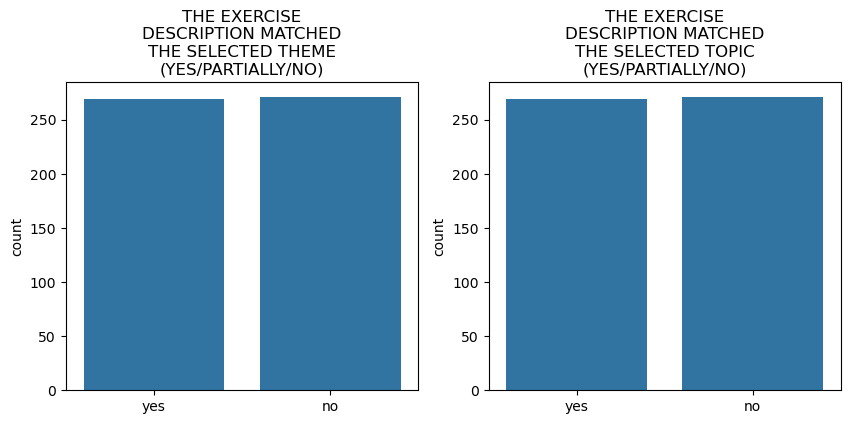

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

plot_distributions(concated_with_pruned, ax)

plt.show()

In [23]:
# Rename columns
final_df = concated_with_pruned.rename(columns={col_name: col_name.replace("/Partially", "") for col_name in EVAL_COLS}, errors="raise")

# Take relevant columns
final_df = final_df[[
    "title",
    "problemDescription",
    "exampleSolution",
    "theme",
    "topic",
    "concept",
    "The exercise description matched the selected theme (Yes/No)", 
    "The exercise description matched the selected topic (Yes/No)",
    "The exercise description matched the selected concept (Yes/No)"
]]

#final_df.head()

,title,problemDescription,exampleSolution,theme,topic,concept,The exercise description matched the selected theme (Yes/No),The exercise description matched the selected topic (Yes/No),The exercise description matched the selected concept (Yes/No)
0,Agatha Christie's Novel Ratings,"Agatha Christie, the famous novelist, has a ra...","{'code': ""import 'dart:io'; main() { print(...",literature,Agatha Christie,conditional statements,yes,yes,yes
1,Painting Assessment,"In a painting class, the paintings are assesse...","{'code': ""import 'dart:io'; main() { print(...",handicrafts,painting,conditional statements,yes,yes,yes
2,Lingonberry Sauce!,Write a program that asks the user for their f...,"{'code': ""import 'dart:io'; main() { print(...",food,Lingonberry sauce,user input,yes,yes,yes
3,Mozart's Symphony,Write a program that asks the user for their f...,"{'code': ""import 'dart:io';main() { print('Wh...",classical music,Wolfgang Amadeus Mozart,program output,yes,yes,yes
4,Calculate Monopoly rent,"In Monopoly, the rent a player must pay when t...","{'code': ""import 'dart:io'; main() { var ho...",board games,Monopoly,arithmetics,yes,yes,yes


In [26]:
final_df.to_csv("../../../data/augmented_dataset.csv", sep=";", index=False)